In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats 

In [6]:
#Calculating LTI 

df = pd.read_csv("credit_risk_dataset.csv")
df['loan_int_rate'] = df['loan_int_rate'].fillna(0)
df['person_emp_length'] = df['person_emp_length'].fillna(0)
df['LTI'] = np.round(df['loan_amnt'] / df['person_income'],2)
df[['loan_amnt', 'person_income', 'LTI']]



,loan_amnt,person_income,LTI
0,35000,59000,0.59
1,1000,9600,0.10
2,5500,9600,0.57
3,35000,65500,0.53
4,35000,54400,0.64
...,...,...,...
32576,5800,53000,0.11
32577,17625,120000,0.15
32578,35000,76000,0.46
32579,15000,150000,0.10


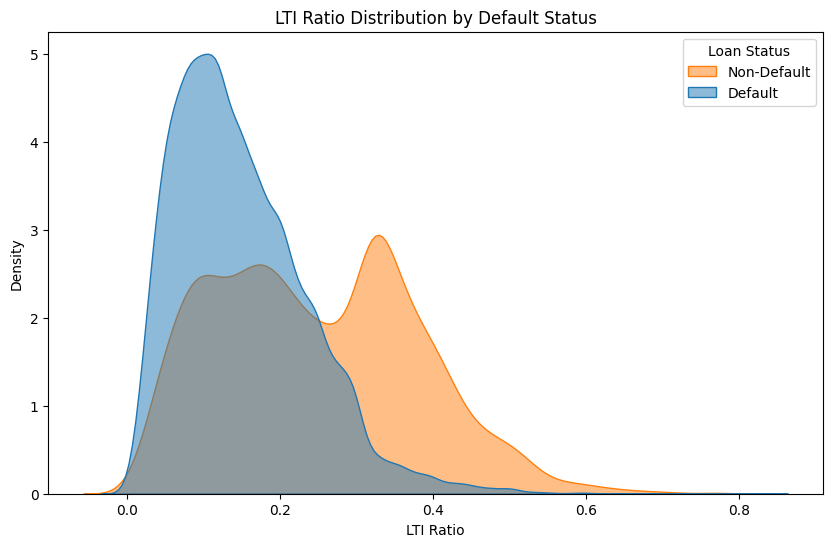

In [7]:
#LTI ratio distribution by default status
plt.figure(figsize=(10, 6))

sns.kdeplot(data=df, x='LTI', hue='loan_status', fill=True, alpha=0.5, common_norm=False)

plt.title('LTI Ratio Distribution by Default Status')
plt.xlabel('LTI Ratio')
plt.ylabel('Density')
plt.legend(title='Loan Status', labels=['Non-Default', 'Default'])
plt.show()

Observation: For defaulted loans, LTI ratios are primarily on the lower end instead of the higher end like what is expected. Normally, the intuintion is that higher LTI ratios will lead to a higher default rate since borrowing much more than the income level is dangerous.

In [8]:
#Data preprocessing
from sklearn.model_selection import train_test_split  #This is so that the code split the data into training section and testing section
from sklearn.preprocessing import LabelEncoder   #Machine learning models can only work with number, this library assign a number to the data

cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
label = LabelEncoder()
for col in cat_cols:
    df[col] = label.fit_transform(df[col])

x = df.drop(columns=['loan_status'])
y = df['loan_status']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=67)



In [9]:
#Logistic Regression model
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

lr_model = LogisticRegression(max_iter=1000, random_state=67)
lr_model.fit(x_train_scaled, y_train)

print("Logistic Regression trained")

Logistic Regression trained


In [10]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=67)
rf_model.fit(x_train, y_train)

print("Random Forest trained")

Random Forest trained


In [11]:
#XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=67, eval_metric='logloss')
xgb_model.fit(x_train, y_train)

print("XGBoost trained")

XGBoost trained


In [12]:
#Results
from sklearn.metrics import classification_report, roc_auc_score

models = {
    'Logistic Regression': (lr_model, x_test_scaled),
    'Random Forest': (rf_model, x_test),
    'XGBoost': (xgb_model, x_test)
}

for name, (model, X) in models.items():
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    print(f"\n{'='*40}")
    print(f"{name}  |  AUC-ROC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Non-Default', 'Default']))


Logistic Regression  |  AUC-ROC: 0.8614
              precision    recall  f1-score   support

 Non-Default       0.87      0.95      0.91      5109
     Default       0.74      0.49      0.59      1408

    accuracy                           0.85      6517
   macro avg       0.80      0.72      0.75      6517
weighted avg       0.84      0.85      0.84      6517


Random Forest  |  AUC-ROC: 0.9336
              precision    recall  f1-score   support

 Non-Default       0.93      0.99      0.96      5109
     Default       0.97      0.71      0.82      1408

    accuracy                           0.93      6517
   macro avg       0.95      0.85      0.89      6517
weighted avg       0.93      0.93      0.93      6517


XGBoost  |  AUC-ROC: 0.9510
              precision    recall  f1-score   support

 Non-Default       0.93      0.99      0.96      5109
     Default       0.95      0.75      0.84      1408

    accuracy                           0.94      6517
   macro avg       0.94

AUG-ROC Score: It tells you how well a model can distinguish between these two classes across all possible decision thresholds

Key Takeaways: 
1. XGBoost is the best overall model, catching 75% of defaulters and when it predicts defaults it is right 95% of the time. The model also has the highest AUG-ROC score at .9510
2. All three models perform better at predicting non-default than default loan. This is expected give the class imbalance (78/22). Further analysis needed.

In [13]:
#Oversampling to mitigate the class imbalance problem
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=67)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

Before SMOTE: {0: 20364, 1: 5700}
After SMOTE: {0: 20364, 1: 20364}


In [14]:
#Logistic Regression with SMOTE
x_train_smote_scaled = scaler.fit_transform(x_train_smote)
lr_model_smote = LogisticRegression(max_iter=1000, random_state=67)
lr_model_smote.fit(x_train_smote_scaled, y_train_smote)
print("Logistic Regression Model trained")

Logistic Regression Model trained


In [15]:
#Random Forest
rf_model_smote = RandomForestClassifier(n_estimators=100, random_state=67)
rf_model_smote.fit(x_train_smote, y_train_smote)
print("Random Forest trained")

Random Forest trained


In [16]:
#XGBoost
xgb_model_smote = XGBClassifier(n_estimators=100, random_state=67, eval_metric='logloss')
xgb_model_smote.fit(x_train_smote, y_train_smote)
print("XGBoost trained")

XGBoost trained


In [17]:
models_smote = {
    'Logistic Regression': (lr_model_smote, x_test_scaled),
    'Random Forest': (rf_model_smote, x_test),
    'XGBoost': (xgb_model_smote, x_test)
}

for name, (model, x) in models_smote.items():
    y_pred = model.predict(x)
    y_prob = model.predict_proba(x)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    print(f"\n{'='*40}")
    print(f"{name} (SMOTE)  |  AUC-ROC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Non-Default', 'Default']))


Logistic Regression (SMOTE)  |  AUC-ROC: 0.8550
              precision    recall  f1-score   support

 Non-Default       0.95      0.66      0.77      5109
     Default       0.41      0.86      0.55      1408

    accuracy                           0.70      6517
   macro avg       0.68      0.76      0.66      6517
weighted avg       0.83      0.70      0.73      6517


Random Forest (SMOTE)  |  AUC-ROC: 0.9274
              precision    recall  f1-score   support

 Non-Default       0.93      0.94      0.94      5109
     Default       0.79      0.75      0.77      1408

    accuracy                           0.90      6517
   macro avg       0.86      0.85      0.85      6517
weighted avg       0.90      0.90      0.90      6517


XGBoost (SMOTE)  |  AUC-ROC: 0.9440
              precision    recall  f1-score   support

 Non-Default       0.93      0.98      0.96      5109
     Default       0.91      0.75      0.83      1408

    accuracy                           0.93      6517

Takeaways:
1. The general trend across the 3 techniques is that recall increased but precision take a hit 
2. XGBoost without SMOTE actually outperformed XGBoost with SMOTE acoording on AUG-ROC score. 

In [18]:
#Gini coefficient and KS statistics
def banking_metrics(name, model, x, y_test):
    y_prob = model.predict_proba(x)[:,1]

    auc = roc_auc_score(y_test, y_prob)
    gini = 2 * auc - 1

    defaulters = y_prob[y_test == 1]
    non_defaulters = y_prob[y_test == 0]
    ks_stat, _ = stats.ks_2samp(defaulters, non_defaulters)
    
    print(f"\n{'='*40}")
    print(f"{name}")
    print(f"  AUC-ROC  : {auc:.4f}")
    print(f"  Gini     : {gini:.4f}")
    print(f"  KS Stat  : {ks_stat:.4f}")

banking_metrics('Logistic Regression', lr_model, x_test_scaled, y_test)
banking_metrics('Random Forest',       rf_model, x_test,        y_test)
banking_metrics('XGBoost',             xgb_model, x_test,       y_test) 


Logistic Regression
  AUC-ROC  : 0.8614
  Gini     : 0.7229
  KS Stat  : 0.5755

Random Forest
  AUC-ROC  : 0.9336
  Gini     : 0.8672
  KS Stat  : 0.7374

XGBoost
  AUC-ROC  : 0.9510
  Gini     : 0.9021
  KS Stat  : 0.7644


Key takeaway: XGBoost is the production-ready model

c:\python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


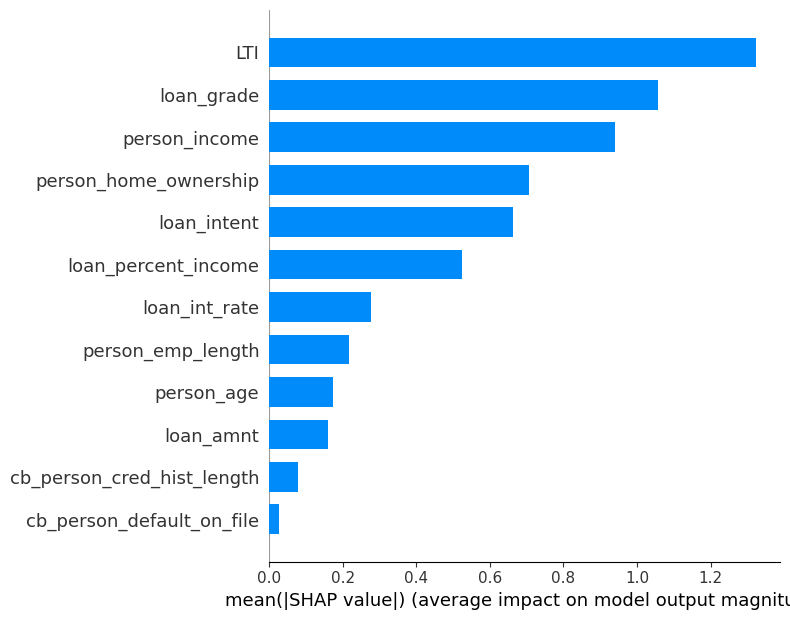

In [19]:
#SHAP - Explain why XGBoost model make its determination
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(x_test)

shap.summary_plot(shap_values, x_test, plot_type="bar")
